In [2]:
# Run this setup only in Google Colab
import os
import subprocess
import sys

try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/Colab Notebooks/ml2_trabalhos_2026")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", ".", "--no-deps"])
except ModuleNotFoundError:
    print("Not running in Colab; skipping Drive mount and install steps.")

Not running in Colab; skipping Drive mount and install steps.


# Trabalho 3 — Marcas d’Água em Dados para Auditoria de Modelos Generativos

> **Pergunta central:** como podemos marcar um conjunto de dados de forma que, se ele for usado no treinamento de um modelo generativo, seja possível auditar posteriormente esse uso?

Neste trabalho usaremos **Variational Autoencoder** como nosso método generativo base, e investigaremos estratégias para **auditoria de uso de dados em modelos generativos**. A situação é a seguinte: o dono de uma base de dados disponibiliza um conjunto de imagens, mas quer preservar a capacidade de verificar, posteriormente, se essas imagens foram usadas por terceiros no treinamento de um modelo generativo.

Para isso, vamos estudar a ideia de inserir uma **marca d’água nos dados de treino**.
Vamos fazer esse estudo usando os dados do MNIST.

Exploraremos duas estratégias:
1. **Marca visível** — patch fixo no canto da imagem. Fácil de detectar, trivialmente removível.
2. **Marca spread-spectrum** — textura pseudo-aleatória de baixa amplitude. Idealmente imperceptível ao olho, detectável via correlação com a chave secreta.

E faremos um **estudo de ablação** variando amplitude, fração marcada e o número de amostras usadas para a auditoria.

**Entregáveis.**
1. Notebook preenchido e executado.
2. Pesos dos VAEs treinados (limpo, marca visível, marca spread-spectrum).
3. Respostas das questões com evidências numéricas dos seus próprios resultados.

**Regras.** Use PyTorch. Fixe seeds. Não apague células do enunciado.

## Parte 0 — Setup e reprodutibilidade

**Tarefa 0.1.** Fixe as seeds aleatórias e configure o dispositivo.

**Tarefa 0.2.** Imprima as versões de `torch` e `torchvision`.

**Tarefa 0.3.** Defina `student_run_tag` (suas iniciais + data) — use ao salvar artefatos.

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

SEED       = 42    # semente do experimentador: splits, pesos, etc.
OWNER_SEED = 1234  # semente do dono dos dados: gera o padrão secreto


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"Torch: {torch.__version__}  |  Torchvision: {__import__('torchvision').__version__}")

student_run_tag = "BIA_2026-05-27"   # ex: "DA_2026-05-22"
output_dir = Path("trabalho3_outputs") / student_run_tag
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {output_dir}")

Dispositivo: cuda
Torch: 2.11.0+cu128  |  Torchvision: 0.26.0+cu128
Output dir: trabalho3_outputs/BIA_2026-05-27


## Parte 1 — VAE no MNIST

Antes de pensar em marca d'água, precisamos de um modelo generativo razoável. Vamos construir um VAE simples no MNIST.

### 1.1 Dados

**Tarefa 1.1.** Carregue o MNIST de treino e teste com `torchvision.datasets.MNIST` (transformação: apenas `ToTensor()`).

In [4]:
transform = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data", train = True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Treino: {len(train_ds):,}  |  Teste: {len(test_ds):,}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 8.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 240kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 28.6MB/s]

Treino: 60,000  |  Teste: 10,000


### 1.2 Arquitetura do VAE

Um VAE é composto por:
- **Encoder** $q_\phi(z \mid x)$: projeta a imagem no espaço latente, produzindo $\mu$ e $\log\sigma^2$.
- **Reparametrização**: $z = \mu + \sigma \odot \epsilon$, $\epsilon \sim \mathcal{N}(0, I)$.
- **Decoder** $p_\theta(x \mid z)$: reconstrói a imagem a partir de $z$ (saída em $[0,1]$ via sigmoid).

**Tarefa 1.2.** Implemente `Encoder`, `Decoder`, `VAE`. Use uma MLP simples (camadas escondidas de 512 e 256 unidades com ReLU). A dimensão latente (`LATENT_DIM`) é um hiperparâmetro configurável — para MNIST, valores entre 2 e 32 produzem modelos razoáveis.

In [5]:


class Encoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        # Rede base: Linear 784 -> 512 -> 256 com ReLU
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        # Camadas de saída para os parâmetros da distribuição latente
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_log_var = nn.Linear(256, latent_dim)

    def forward(self, x):
        # Achatar a imagem de (B, 1, 28, 28) para (B, 784)
        x_flat = x.view(-1, 784)
        hidden = self.net(x_flat)
        
        mu = self.fc_mu(hidden)
        log_var = self.fc_log_var(hidden)
        return mu, log_var

class Decoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        # Rede inversa: latent_dim -> 256 -> 512 -> 784 com ReLU e Sigmoid no final
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid()  # Garante saídas em [0, 1] para os pixels
        )

    def forward(self, z):
        out_flat = self.net(z)
        # Redimensionar de volta para o formato de imagem (B, 1, 28, 28)
        return out_flat.view(-1, 1, 28, 28)


class VAE(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparametrize(self, mu, log_var):
        # z = mu + sigma * epsilon
        # Onde sigma = exp(0.5 * log_var)
        std = torch.exp(0.5 * log_var)
        epsilon = torch.randn_like(std)  # Amostra N(0, I) com o mesmo shape/device de std
        return mu + std * epsilon

    def forward(self, x):
        # 1. Encode
        mu, log_var = self.encoder(x)
        # 2. Sample (Reparametrizar)
        z = self.reparametrize(mu, log_var)
        # 3. Decode
        x_hat = self.decoder(z)
        
        return x_hat, mu, log_var



In [6]:
LATENT_DIM = 8   # escolha um valor razoável (sugestão: entre 2 e 32 para MNIST)
IMG_DIM = 28 * 28


model = VAE(LATENT_DIM).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"LATENT_DIM = {LATENT_DIM}  |  Parâmetros: {n_params:,}")

LATENT_DIM = 8  |  Parâmetros: 1,073,440


### 1.3 Função de perda — ELBO

O VAE maximiza o **Evidence Lower Bound (ELBO)**:

$$\mathcal{L}(\theta, \phi; x) = \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x \mid z)]}_{\text{reconstrução}} - \underbrace{D_{KL}(q_\phi(z|x) \,\|\, p(z))}_{\text{regularização}}$$

Para imagens com pixels em $[0,1]$, usamos **BCE** (Bernoulli) como modelo de reconstrução. Como prior, $p(z) = \mathcal{N}(0, I)$, e a KL tem forma fechada:

$$D_{KL}(q_\phi(z|x) \| \mathcal{N}(0,I)) = -\frac{1}{2}\sum_j \left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$

**Tarefa 1.3.** Implemente `vae_loss` que retorna `(loss_total, recon, kl)`. Use BCE com `reduction="sum"` (some sobre pixels e batch).

In [7]:
def vae_loss(x, x_hat, mu, log_var):
    # 1. Erro de Reconstrução: BCE entre x_hat e x somado sobre pixels e batch
    # Garante que x_hat e x tenham o mesmo formato achatado para evitar problemas de dimensão
    recon = F.binary_cross_entropy(x_hat, x, reduction="sum")
    
    # 2. Divergência KL (forma fechada para prior N(0, I))
    # Fórmula: -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    # Somamos sobre todas as dimensões latentes e sobre todas as amostras do batch
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    
    # 3. A perda total que queremos minimizar é a soma dos dois termos
    loss_total = recon + kl
    
    return loss_total, recon, kl

### 1.4 Treinamento

Treine por **30 épocas** com Adam (lr=1e-3). A loss é a ELBO (somada sobre o batch, dividida no final por `len(dataset)` para reportar por amostra).

**Tarefa 1.4.** Implemente o loop de treino e salve o histórico de loss/recon/KL para treino e teste.

In [8]:
EPOCHS = 30
LR = 1e-3

In [9]:


optimizer = torch.optim.Adam(model.parameters(), lr=LR)
history = {"train_loss": [], "train_recon": [], "train_kl": [],
           "test_loss":  [], "test_recon":  [], "test_kl":  []}


def run_epoch(loader, train: bool):
    # 1. Alternar entre model.train() e model.eval() baseado na flag 'train'
    if train:
        model.train()
    else:
        model.eval()

    # Inicializa os acumuladores de perda para a época
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0

    # Ativa ou desativa os gradientes dinamicamente dependendo se é treino ou teste
    with torch.set_grad_enabled(train):
        for x, _ in loader:
            # Mover os dados para o dispositivo correto (GPU ou CPU)
            x = x.to(device)

            # Se for treino, zerar os gradientes acumulados do otimizador
            if train:
                optimizer.zero_grad()

            # Passar a imagem pelo VAE para obter a reconstrução e os parâmetros latentes
            x_hat, mu, log_var = model(x)

            # Calcular os três componentes da perda usando a função definida na Tarefa 1.3
            loss, recon, kl = vae_loss(x, x_hat, mu, log_var)

            # Se for treino, calcular os gradientes e atualizar os pesos
            if train:
                loss.backward()
                optimizer.step()

            # Acumular os valores brutos (escalares) de perda ao longo do loader
            # Usamos .item() para desanexar o valor do grafo e economizar memória RAM
            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()

    # 2. Calcular as médias por amostra dividindo pelo total de imagens no dataset
    num_samples = len(loader.dataset)
    
    mean_loss = total_loss / num_samples
    mean_recon = total_recon / num_samples
    mean_kl = total_kl / num_samples

    # Retorna uma tupla contendo as três médias por amostra
    return mean_loss, mean_recon, mean_kl


for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, train=True)
    te = run_epoch(test_loader,  train=False)
    for key, value in zip(["loss", "recon", "kl"], tr):
        history[f"train_{key}"].append(value)
    for key, value in zip(["loss", "recon", "kl"], te):
        history[f"test_{key}"].append(value)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Ep {epoch:3d}/{EPOCHS} | tr loss {tr[0]:.2f}  recon {tr[1]:.2f}  kl {tr[2]:.2f} | te loss {te[0]:.2f}")

torch.save(model.state_dict(), output_dir / f"vae_clean_latent{LATENT_DIM}.pt")
print("Salvo.")

Ep   1/30 | tr loss 194.91  recon 190.17  kl 4.74 | te loss 151.16
Ep   5/30 | tr loss 116.15  recon 101.06  kl 15.09 | te loss 114.44
Ep  10/30 | tr loss 109.67  recon 93.81  kl 15.86 | te loss 109.59
Ep  15/30 | tr loss 106.90  recon 90.69  kl 16.21 | te loss 108.02
Ep  20/30 | tr loss 105.04  recon 88.58  kl 16.46 | te loss 106.16
Ep  25/30 | tr loss 103.71  recon 87.12  kl 16.59 | te loss 105.02
Ep  30/30 | tr loss 102.76  recon 86.03  kl 16.74 | te loss 104.18
Salvo.


### 1.5 Visualizações

Produza as seguintes visualizações (use o conjunto de teste para a maioria, com seeds fixas).

**Tarefa 1.5a.** Plote as **curvas de treino** (loss total, recon, KL) para treino e teste.

**Tarefa 1.5b.** Mostre **10 reconstruções** lado a lado com os originais.

**Tarefa 1.5c.** Projete o conjunto de teste no espaço latente (use $\mu$, não amostra) e plote um scatter colorido por dígito. *Se `LATENT_DIM > 2`, faça uma redução de dimensionalidade para 2D antes de plotar — use PCA via `numpy.linalg.svd` (centralize os dados antes do SVD; não use sklearn).*

**Tarefa 1.5d.** Amostre 20 imagens do prior ($z \sim \mathcal{N}(0, I)$) e mostre o que o decoder gera.

<>:150: SyntaxWarning: invalid escape sequence '\s'
<>:150: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_16719/1942771424.py:150: SyntaxWarning: invalid escape sequence '\s'
  plt.suptitle("Imagens Geradas Artificialmente a partir do Prior $z \sim \mathcal{N}(0, I)$")


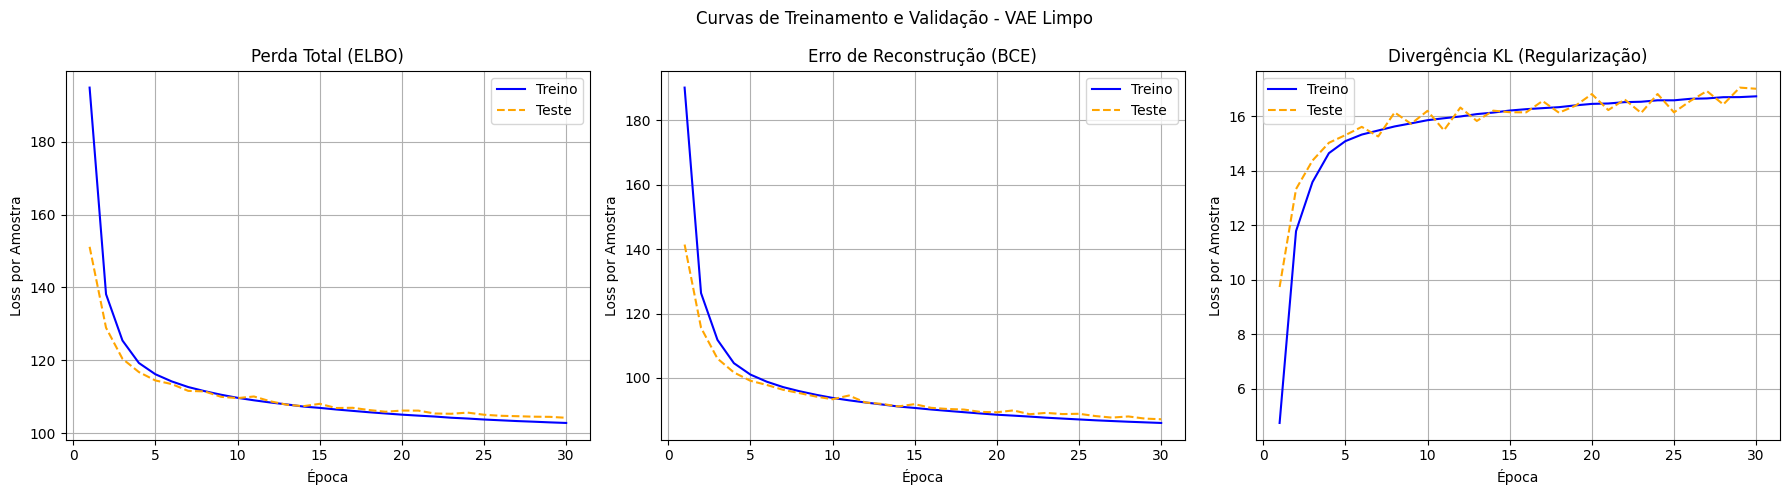

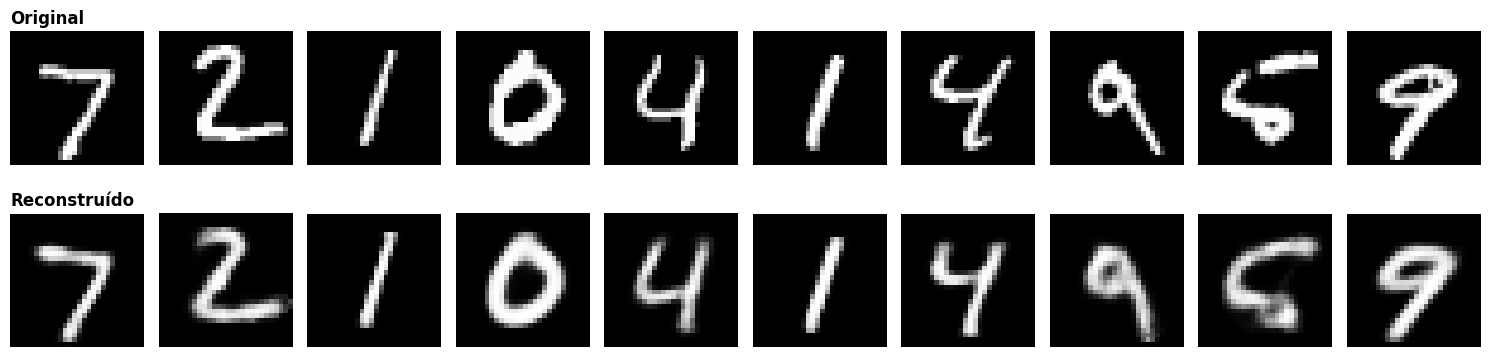

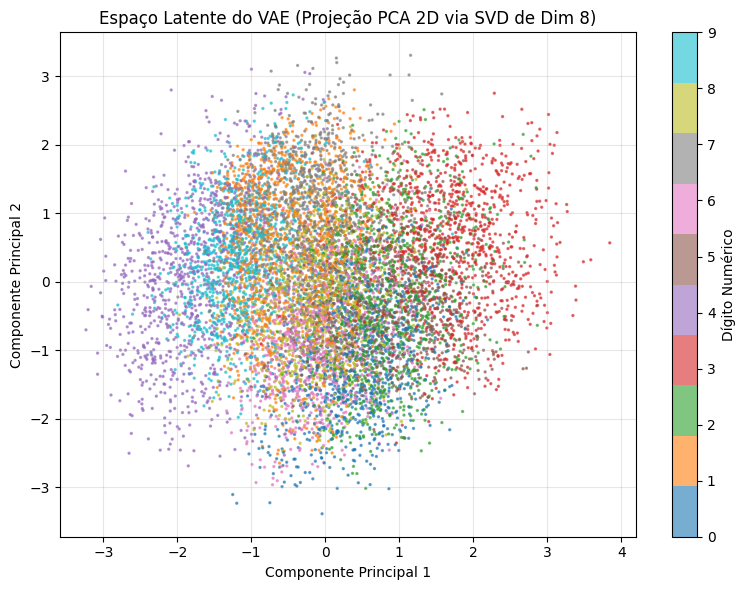

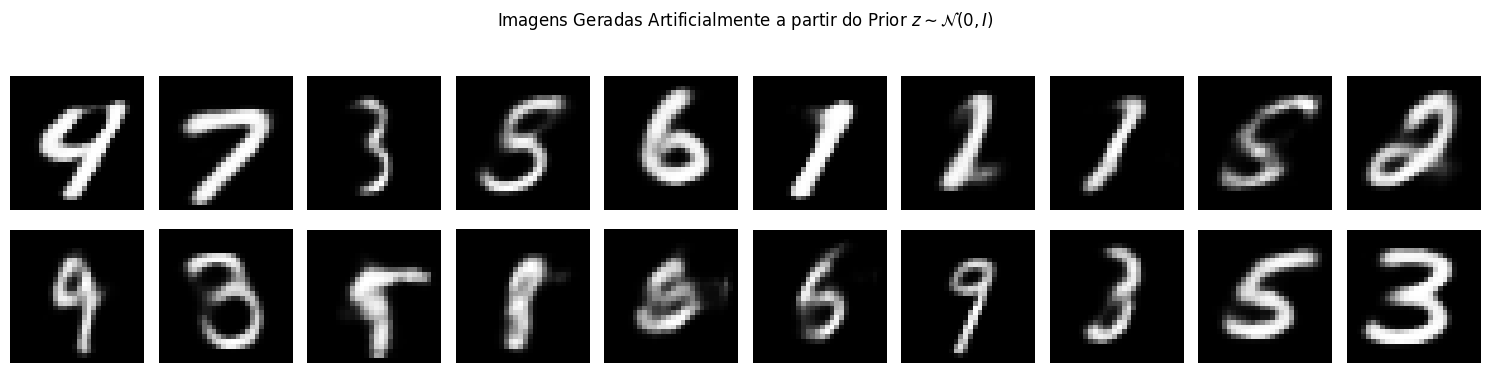

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Garante que o modelo está no modo de avaliação e no dispositivo correto
model.eval()

# ---------------------------------------------------------------------------
# Tarefa 1.5a. Curvas de Treino (Loss Total, Recon, KL)
# ---------------------------------------------------------------------------
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: Loss Total
axs[0].plot(epochs_range, history["train_loss"], label="Treino", color="blue")
axs[0].plot(epochs_range, history["test_loss"], label="Teste", color="orange", linestyle="--")
axs[0].set_title("Perda Total (ELBO)")
axs[0].set_xlabel("Época")
axs[0].set_ylabel("Loss por Amostra")
axs[0].legend()
axs[0].grid(True)

# Subplot 2: Perda de Reconstrução
axs[1].plot(epochs_range, history["train_recon"], label="Treino", color="blue")
axs[1].plot(epochs_range, history["test_recon"], label="Teste", color="orange", linestyle="--")
axs[1].set_title("Erro de Reconstrução (BCE)")
axs[1].set_xlabel("Época")
axs[1].set_ylabel("Loss por Amostra")
axs[1].legend()
axs[1].grid(True)

# Subplot 3: Divergência KL
axs[2].plot(epochs_range, history["train_kl"], label="Treino", color="blue")
axs[2].plot(epochs_range, history["test_kl"], label="Teste", color="orange", linestyle="--")
axs[2].set_title("Divergência KL (Regularização)")
axs[2].set_xlabel("Época")
axs[2].set_ylabel("Loss por Amostra")
axs[2].legend()
axs[2].grid(True)

plt.suptitle("Curvas de Treinamento e Validação - VAE Limpo")
plt.tight_layout()
plt.savefig(output_dir / "1.5a_curvas_treinamento.png", dpi=150)
plt.show()


# ---------------------------------------------------------------------------
# Tarefa 1.5b. Mostre 10 reconstruções lado a lado com os originais
# ---------------------------------------------------------------------------
# Pegar um lote fixo do test_loader
with torch.no_grad():
    x_test, _ = next(iter(test_loader))
    x_test = x_test.to(device)
    x_hat, _, _ = model(x_test)

# Mover de volta para CPU e transformar em numpy para plotar
originais = x_test.cpu().numpy()
reconstrucoes = x_hat.cpu().numpy()

fig, axs = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    # Linha 0: Originais
    axs[0, i].imshow(originais[i].squeeze(), cmap="gray")
    axs[0, i].axis("off")
    if i == 0:
        axs[0, i].set_title("Original", loc="left", fontsize=12, fontweight="bold")
        
    # Linha 1: Reconstruções
    axs[1, i].imshow(reconstrucoes[i].squeeze(), cmap="gray")
    axs[1, i].axis("off")
    if i == 0:
        axs[1, i].set_title("Reconstruído", loc="left", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(output_dir / "1.5b_reconstrucoes.png", dpi=150)
plt.show()


# ---------------------------------------------------------------------------
# Tarefa 1.5c. Espaço Latente 2D via PCA Manual (SVD)
# ---------------------------------------------------------------------------
all_mus = []
all_labels = []

# Coleta as médias (mu) de todo o conjunto de teste
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        mu, _ = model.encoder(x)
        all_mus.append(mu.cpu().numpy())
        all_labels.append(y.numpy())

all_mus = np.concatenate(all_mus, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Aplicação do PCA manual se LATENT_DIM > 2 usando SVD
if LATENT_DIM > 2:
    # 1. Centralizar os dados (subtrair a média de cada coluna)
    mu_mean = np.mean(all_mus, axis=0)
    mus_centered = all_mus - mu_mean
    
    # 2. Computar o SVD: X = U * S * Vt
    U, S, Vt = np.linalg.svd(mus_centered, full_matrices=False)
    
    # 3. Projetar os dados nas duas primeiras componentes principais (as 2 primeiras colunas de V, ou seja, linhas de Vt)
    # Vt shape é (LATENT_DIM, LATENT_DIM). Pegamos as duas primeiras linhas e transpomos: shape (LATENT_DIM, 2)
    W2 = Vt[:2, :].T
    latent_2d = np.dot(mus_centered, W2)
    title_suffix = f" (Projeção PCA 2D via SVD de Dim {LATENT_DIM})"
else:
    latent_2d = all_mus
    title_suffix = " (Direto 2D)"

# Plotar o scatter colorido por dígito
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(latent_2d[:, 0], latent_2d[:, 1], c=all_labels, cmap="tab10", alpha=0.6, s=2)
colorbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
colorbar.set_label("Dígito Numérico")
ax.set_title(f"Espaço Latente do VAE{title_suffix}")
ax.set_xlabel("Componente Principal 1" if LATENT_DIM > 2 else "Dimensão Latente 1")
ax.set_ylabel("Componente Principal 2" if LATENT_DIM > 2 else "Dimensão Latente 2")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / "1.5c_espaco_latente.png", dpi=150)
plt.show()


# ---------------------------------------------------------------------------
# Tarefa 1.5d. Amostras do Prior (Geração pura z ~ N(0, I))
# ---------------------------------------------------------------------------
# Fixar a semente local para reprodutibilidade da geração de imagens
torch.manual_seed(SEED)

with torch.no_grad():
    # Amostra 20 vetores aleatórios normais do prior
    z_prior = torch.randn(20, LATENT_DIM).to(device)
    # Passa pelo decoder para gerar as imagens
    geradas = model.decoder(z_prior).cpu().numpy()

# Mostrar as 20 imagens organizadas em uma grade de 2x10
fig, axs = plt.subplots(2, 10, figsize=(15, 4))
for i in range(20):
    row = i // 10
    col = i % 10
    axs[row, col].imshow(geradas[i].squeeze(), cmap="gray")
    axs[row, col].axis("off")

plt.suptitle("Imagens Geradas Artificialmente a partir do Prior $z \sim \mathcal{N}(0, I)$")
plt.tight_layout()
plt.savefig(output_dir / "1.5d_amostras_prior.png", dpi=150)
plt.show()

### Questão 1 — Análise do VAE base

**a)** Compare as curvas de treino e teste. O modelo apresenta underfitting, overfitting, ou está bem ajustado? Justifique com o gap treino/teste e a tendência das curvas.

**b)** Compare reconstruções com amostras do prior. Em qual das duas o VAE produz imagens melhores? Por quê?

**c)** Na projeção 2D do espaço latente (direta se `LATENT_DIM=2`, via PCA caso contrário), as classes ficam separadas? Existem regiões vazias? Conecte a estrutura latente à qualidade das amostras geradas.

**RESPOSTAS**

**Questão a)** 

O modelo está bem ajustado, verificando ao final de 30 épocas, a perda total de treino atinge aproximadamente 103 e a perda de teste chega a aproximadamente 104, sendo a diferença entre treino e teste um valor pequeno, o que descarta sintoma de overfitting. E sobre as tendências das curvas, observando o gráfico de linha gerado acima, o erro de reconstrução (BCE) decresce de forma suave tanto para o treino quanto para o teste. Além disso, a divergência KL aumenta no início e atinge algo estável a partir da época 15. Logo, podemos dizer que o modelo não sofre de underfitting e encontra o balanço ideal entre reconstruir e regularizar.



**Questão b)**

O VAE produz imagens visivelmente superiores e mais nítidas nas reconstruções. Na reconstrução, o Encoder fornece uma estimativa direcionada de $\mu$ e $\sigma$ para uma imagem que realmente existe. O Decoder recebe um vetor latente condicionado à identidade daquela imagem real, gerando traços mais limpos e formatos exatos. Já na amostragem pura, estamos sorteando pontos cegos dentro do espaço gaussiano prior. Como a regularização KL não é perfeita, algumas regiões sorteadas caem nas "fronteiras" ou zonas de transição entre dígitos no espaço latente. Isso faz com que algumas amostras geradas pareçam um pouco borradas, inconsistentes ou misturas ambíguas de dígitos.



**Questão c)**

Os grupos não formam grupos isolados, mas se organizam em um mapa contínuo com transições suaves. Alguns dígitos com formas diferentes (como 1 e 7) ficam em extremos distantes, enquanto dígitos parecidos (como 4,9 e 7) se sobrepõem parcialmente nas fronteiras. Sobre regiões vazias, o espaco central é totalmente preenchido, sem zonas vazias, o que força o Encoder a colar os dados em uma dstribuição normal. Como não existem vazios no espaço latente, qualquer vetor aleatório $z$ sorteado do prior cairá em uma região com significado geométrico. Isso garante que o Decoder sempre gere dígitos legíveis e realistas, evitando a produção de ruído aleatório ou imagens pretas. 


## Parte 2 — Marca d'água visível (warmup do auditor)

A versão mais simples do problema: o dono dos dados estampa um **patch branco fixo** num canto das imagens. Esta marca é trivialmente visível, mas serve como referência para entendermos o "limite superior" da detectabilidade.

### 2.1 Definir a marca e o dataset

A marca é um quadrado branco $4 \times 4$ no canto inferior direito (posição `[22:26, 22:26]`), valor $1.0$. Marcamos 20% das imagens de treino, selecionadas aleatoriamente com seed fixa.

**Tarefa 2.1.** Implemente:
- A função `apply_visible_watermark(img)`.
- A classe `VisibleWatermarkedMNIST` que envolve `train_ds` e marca aleatoriamente uma fração das imagens, mantendo `watermarked_indices` para análise posterior.

In [11]:
PATCH_ROW, PATCH_COL = 22, 22
PATCH_SIZE = 4
WM_FRACTION = 0.20

In [12]:
def apply_visible_watermark(img: torch.Tensor) -> torch.Tensor:
    # Cria uma cópia para não alterar a imagem original do dataset base
    img_wm = img.clone()
    
    
    #  o shape da imagem é (Canais, Altura, Largura), ou seja, (1, 28, 28)
    img_wm[:, PATCH_ROW:PATCH_ROW + PATCH_SIZE, PATCH_COL:PATCH_COL + PATCH_SIZE] = 1.0
    
    return img_wm


class VisibleWatermarkedMNIST(Dataset):
    def __init__(self, base_dataset, fraction=WM_FRACTION, seed=SEED):
        self.base_dataset = base_dataset
        self.fraction = fraction
        
        # 1. Determinar a quantidade de imagens que serão marcadas
        num_total = len(self.base_dataset)
        num_watermarked = int(num_total * self.fraction)
        
        # 2. Amostrar índices usando o gerador recomendado pelo professor
        rng = np.random.default_rng(seed)
        # Sorteia 'num_watermarked' índices sem repetição dentro do intervalo total
        chosen_indices = rng.choice(num_total, size=num_watermarked, replace=False)
        
        # Guardamos como lista/array para análise e como 'set' para busca rápida no __getitem__
        self.watermarked_indices = sorted(list(chosen_indices))
        self.watermarked_set = set(self.watermarked_indices)

    def __len__(self):
        # O tamanho do dataset marcado é exatamente idêntico ao original
        return len(self.base_dataset)

    def __getitem__(self, idx):
        # Pega a imagem e o rótulo originais do dataset base
        img, label = self.base_dataset[idx]
        
        # Se o índice atual estiver na lista dos sorteados, aplica a marca d'água
        if idx in self.watermarked_set:
            img = apply_visible_watermark(img)
            
        return img, label

vis_ds = VisibleWatermarkedMNIST(train_ds)
print(f"Marcadas: {len(vis_ds.watermarked_indices):,} / {len(vis_ds):,}")

Marcadas: 12,000 / 60,000


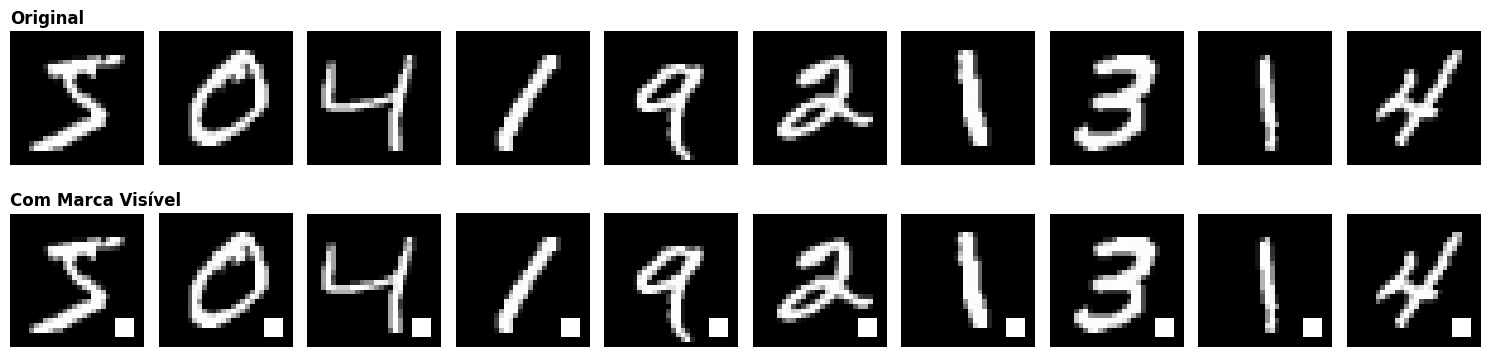

In [13]:
# Fixamos uma semente para garantir que as mesmas 10 imagens apareçam sempre
torch.manual_seed(SEED)

fig, axs = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):
    # 1. Pegar a imagem original diretamente do dataset base (sem marca)
    img_original, _ = train_ds[i]
    
    # 2. Gerar a versão marcada usando a função que você implementou
    img_marcada = apply_visible_watermark(img_original)
    
    # Mover para numpy e remover o canal extra de cor para o matplotlib (.squeeze())
    orig_np = img_original.squeeze().numpy()
    marc_np = img_marcada.squeeze().numpy()
    
    # Linha 0: Imagens Originais Limpas
    axs[0, i].imshow(orig_np, cmap="gray")
    axs[0, i].axis("off")
    if i == 0:
        axs[0, i].set_title("Original", loc="left", fontsize=12, fontweight="bold")
        
    # Linha 1: Imagens com a Marca d'Água Visível (Patch no canto inferior direito)
    axs[1, i].imshow(marc_np, cmap="gray")
    axs[1, i].axis("off")
    if i == 0:
        axs[1, i].set_title("Com Marca Visível", loc="left", fontsize=12, fontweight="bold")

plt.tight_layout()
# Salva o gráfico gerado dentro da sua pasta de outputs conforme orientação do professor
plt.savefig(output_dir / "2.1_originais_vs_marcadas.png", dpi=150)
plt.show()

### 2.2 Treinar o VAE marcado

Treine um novo VAE (`vae_vis`) com **a mesma arquitetura** do `model` (mesma `LATENT_DIM`) mas usando `vis_ds` como dataset de treino. Use 30 épocas, Adam lr=1e-3.

**Dica.** Modularize: escreva uma função `train_vae(loader, latent_dim, epochs, label)` que cria, treina e retorna um novo VAE. Vamos reutilizá-la várias vezes nas próximas partes.

In [14]:
def train_vae(loader, latent_dim, epochs, label, lr=1e-3):
    # Fixar sementes locais para que o treino deste modelo seja reprodutível
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
        
    print(f"\n--- Iniciando Treinamento do VAE [{label.upper()}] (LATENT_DIM={latent_dim}) ---")
    
    # 1. Instanciar o modelo e enviar para o dispositivo correto (GPU/CPU)
    model_instance = VAE(latent_dim).to(device)
    
    # 2. Configurar o Otimizador Adam com a taxa de aprendizado fornecida
    optimizer_instance = torch.optim.Adam(model_instance.parameters(), lr=lr)
    
    # Loop de épocas
    for epoch in range(1, epochs + 1):
        model_instance.train()
        
        total_loss = 0.0
        total_recon = 0.0
        total_kl = 0.0
        
        # Loop interno de lotes (batches)
        for x, _ in loader:
            x = x.to(device)
            
            optimizer_instance.zero_grad()
            
            # Forward pass
            x_hat, mu, log_var = model_instance(x)
            
            # Cálculo da perda por lote (soma dos pixels e amostras)
            loss, recon, kl = vae_loss(x, x_hat, mu, log_var)
            
            # Backward pass e atualização dos pesos
            loss.backward()
            optimizer_instance.step()
            
            # Acumulação das perdas tirando o valor do grafo (.item())
            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()
            
        # Calcular as médias por amostra da época atual
        num_samples = len(loader.dataset)
        mean_loss = total_loss / num_samples
        mean_recon = total_recon / num_samples
        mean_kl = total_kl / num_samples
        
        # 3. Print de resumo a cada 5 épocas ou na primeira/última época
        if epoch % 5 == 0 or epoch == 1 or epoch == epochs:
            print(f"[{label.upper()}] Ep {epoch:3d}/{epochs} | Loss: {mean_loss:.2f} | Recon: {mean_recon:.2f} | KL: {mean_kl:.2f}")
            
    
    return model_instance

# Criar o DataLoader para o dataset que contém a marca d'água visível
vis_loader = DataLoader(vis_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

# Executar a função modular criada acima
vae_vis = train_vae(vis_loader, LATENT_DIM, epochs=30, label="vis")

# Salvar o estado do modelo treinado no diretório correto
torch.save(vae_vis.state_dict(), output_dir / "vae_visible.pt")


--- Iniciando Treinamento do VAE [VIS] (LATENT_DIM=8) ---
[VIS] Ep   1/30 | Loss: 202.78 | Recon: 198.09 | KL: 4.68
[VIS] Ep   5/30 | Loss: 118.89 | Recon: 103.38 | KL: 15.51
[VIS] Ep  10/30 | Loss: 112.34 | Recon: 96.08 | KL: 16.27
[VIS] Ep  15/30 | Loss: 109.42 | Recon: 92.77 | KL: 16.65
[VIS] Ep  20/30 | Loss: 107.52 | Recon: 90.62 | KL: 16.90
[VIS] Ep  25/30 | Loss: 106.12 | Recon: 89.03 | KL: 17.09
[VIS] Ep  30/30 | Loss: 105.09 | Recon: 87.87 | KL: 17.23


### 2.3 Auditoria visual

Use **o mesmo $z$** para gerar amostras de `model` (limpo) e `vae_vis` (com marca). Mostre lado a lado.

**Tarefa 2.3.** Plote 20 amostras de cada modelo (mesmo $z$), em duas linhas — limpo em cima, marcado embaixo.

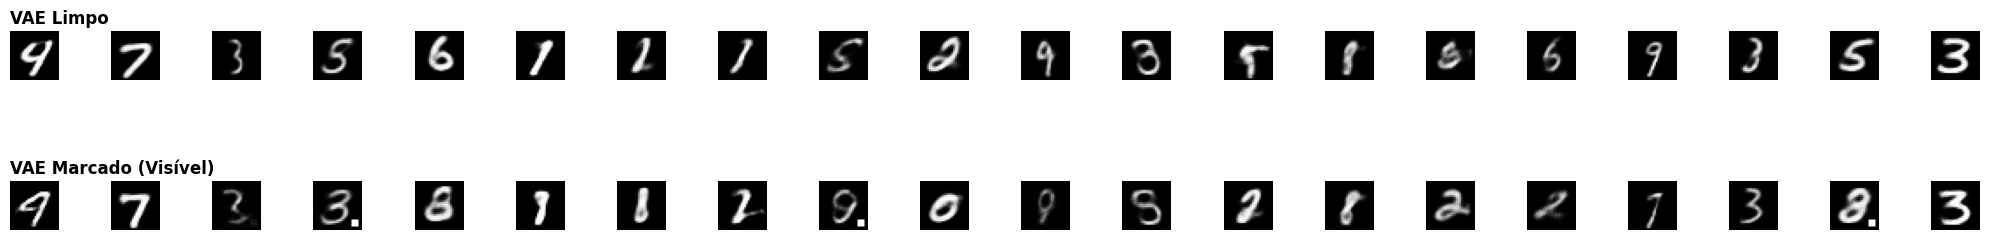

In [15]:
import torch
import matplotlib.pyplot as plt

# 1. Garantir que ambos os modelos estão em modo de avaliação (eval) e no mesmo dispositivo
model.eval()
vae_vis.eval()

# 2. Fixar a semente para garantir a reprodutibilidade dos vetores aleatórios z
torch.manual_seed(SEED)

N = 20

with torch.no_grad():
    # Amostrar o MESMO vetor z do prior standard N(0, I) para ambos os modelos
    # Shape: (20, LATENT_DIM)
    z_shared = torch.randn(N, LATENT_DIM).to(device)
    
    # Decodificar usando o modelo limpo (Parte 1)
    imagens_limpas = model.decoder(z_shared).cpu().numpy()
    
    # Decodificar usando o modelo treinado com marca visível (Parte 2)
    imagens_marcadas = vae_vis.decoder(z_shared).cpu().numpy()

# 3. Construir o grid de plotagem 2x20 (Linha 1: Limpo, Linha 2: Marcado)
fig, axs = plt.subplots(2, N, figsize=(20, 3.5))

for i in range(N):
    # Remover canais extras com .squeeze() para o matplotlib
    img_clean_np = imagens_limpas[i].squeeze()
    img_vis_np = imagens_marcadas[i].squeeze()
    
    # Linha 0: Imagens geradas pelo VAE Limpo (Baseline)
    axs[0, i].imshow(img_clean_np, cmap="gray", vmin=0.0, vmax=1.0)
    axs[0, i].axis("off")
    if i == 0:
        axs[0, i].set_title("VAE Limpo", loc="left", fontsize=12, fontweight="bold")
        
    # Linha 1: Imagens geradas pelo VAE treinado com dados marcados
    axs[1, i].imshow(img_vis_np, cmap="gray", vmin=0.0, vmax=1.0)
    axs[1, i].axis("off")
    if i == 0:
        axs[1, i].set_title("VAE Marcado (Visível)", loc="left", fontsize=12, fontweight="bold")

plt.tight_layout()
# Salvar a figura gerada na pasta de saída
plt.savefig(output_dir / "2.3_auditoria_visual_visivel.png", dpi=150)
plt.show()

### 2.4 Auditoria estatística

Quantifique o sinal calculando o **valor médio de pixel** dentro da região do patch:

$$\text{patch\_mean}(x) = \frac{1}{|P|} \sum_{(i,j) \in P} x_{ij}, \quad P = \{(i,j) : 22 \le i, j < 26\}$$

**Tarefa 2.4.** Implemente `patch_mean(imgs)` (tensor `(N, 1, 28, 28)` → tensor `(N,)`). Compute essa métrica para 4 grupos e plote um bar chart comparativo com erro padrão:
1. Imagens limpas do teste (primeiras 1000).
2. Imagens marcadas do treino (primeiros 1000 índices marcados).
3. 1000 amostras do `model` (VAE limpo).
4. 1000 amostras do `vae_vis`.

Média do patch - Real Limpo:      0.0027
Média do patch - Real Marcado:    1.0000
Média do patch - Gerado Limpo:    0.0026
Média do patch - Gerado Marcado:  0.2251
--> LIFT calculado: 86.42x de aumento de intensidade!


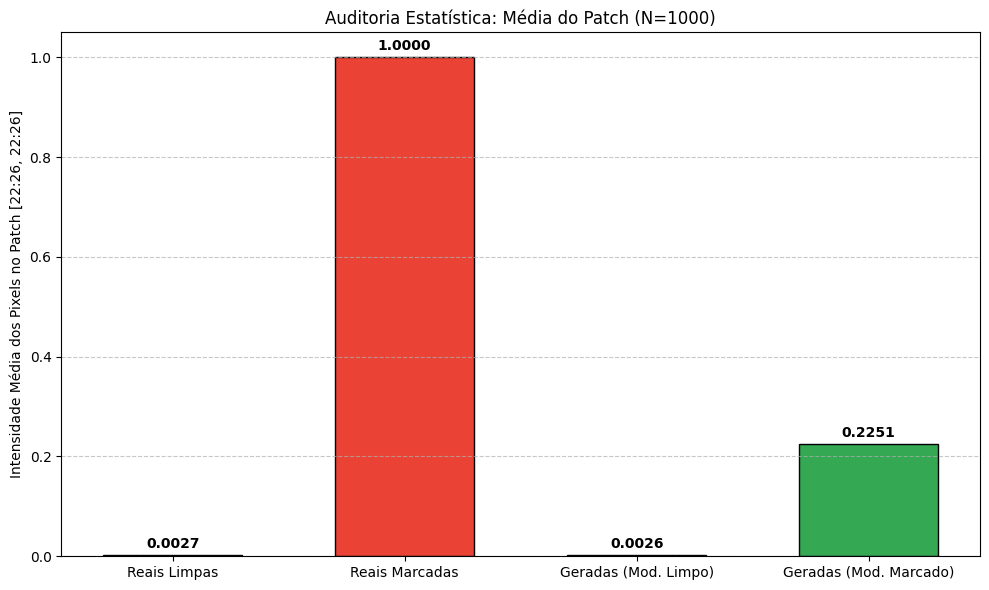

In [16]:
def patch_mean(imgs: torch.Tensor) -> torch.Tensor:
    # imgs tem formato (B, 1, 28, 28)
    # Recortamos a região do patch: todas as imagens do batch, todos os canais, linhas 22 a 25, colunas 22 a 25
    patch_region = imgs[:, :, PATCH_ROW:PATCH_ROW + PATCH_SIZE, PATCH_COL:PATCH_COL + PATCH_SIZE]
    
    # Calculamos a média dos pixels desse recorte.
    # Como queremos a média *por imagem*, reduzimos sobre as dimensões de canais, altura e largura: dim=(1, 2, 3)
    return torch.mean(patch_region, dim=(1, 2, 3))


# ---------------------------------------------------------------------------
# Configuração da Auditoria Estatística (N_AUDIT = 1000)
# ---------------------------------------------------------------------------
N_AUDIT = 1000
torch.manual_seed(SEED) # Reprodutibilidade

with torch.no_grad():
    # 1. Gerar 1000 vetores latentes z do prior
    z_audit = torch.randn(N_AUDIT, LATENT_DIM).to(device)
    
    # 2. Passar o mesmo z pelos dois decoders para gerar as imagens artificiais
    imgs_geradas_limpo = model.decoder(z_audit)
    imgs_geradas_vis   = vae_vis.decoder(z_audit)
    
    # 3. Coletar imagens reais do test_loader para servirem de controle histórico
    # Vamos acumular até dar pelo menos 1000 imagens
    imgs_reais_list = []
    for x, _ in test_loader:
        imgs_reais_list.append(x)
        if sum(len(img) for img in imgs_reais_list) >= N_AUDIT:
            break
    imgs_reais = torch.cat(imgs_reais_list, dim=0)[:N_AUDIT].to(device)
    
    # 4. Criar as imagens reais com a marca física aplicada para servir de limite superior (Upper Bound)
    imgs_reais_marcadas = torch.stack([apply_visible_watermark(img) for img in imgs_reais])

    # 5. Calcular a média do patch para cada um dos 4 grupos
    pm_real_limpo = patch_mean(imgs_reais).cpu().numpy()
    pm_real_marc  = patch_mean(imgs_reais_marcadas).cpu().numpy()
    pm_gen_limpo  = patch_mean(imgs_geradas_limpo).cpu().numpy()
    pm_gen_vis    = patch_mean(imgs_geradas_vis).cpu().numpy()

# 6. Calcular as médias globais de cada grupo para construir o gráfico
vals = [pm_real_limpo.mean(), pm_real_marc.mean(), pm_gen_limpo.mean(), pm_gen_vis.mean()]
labels = ["Reais Limpas", "Reais Marcadas", "Geradas (Mod. Limpo)", "Geradas (Mod. Marcado)"]

# ---------------------------------------------------------------------------
# Cálculo do Lift (Sinal-Ruído)
# ---------------------------------------------------------------------------
# O lift mede quantas vezes a intensidade aumentou no modelo contaminado em relação ao limpo
lift = vals[3] / vals[2]

print(f"Média do patch - Real Limpo:      {vals[0]:.4f}")
print(f"Média do patch - Real Marcado:    {vals[1]:.4f}")
print(f"Média do patch - Gerado Limpo:    {vals[2]:.4f}")
print(f"Média do patch - Gerado Marcado:  {vals[3]:.4f}")
print(f"--> LIFT calculado: {lift:.2f}x de aumento de intensidade!")

# ---------------------------------------------------------------------------
# Geração do Gráfico de Barras
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#4285F4", "#EA4335", "#FBBC05", "#34A853"]

bars = ax.bar(labels, vals, color=colors, edgecolor="black", width=0.6)
ax.set_ylabel("Intensidade Média dos Pixels no Patch [22:26, 22:26]")
ax.set_title(f"Auditoria Estatística: Média do Patch (N={N_AUDIT})")
ax.grid(axis="y", linestyle="--", alpha=0.7)

# Adiciona os valores numéricos em cima de cada barra para facilitar a leitura
for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.4f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 pontos de offset vertical
                textcoords="offset points",
                ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.savefig(output_dir / "2.3_patch_mean_bar_chart.png", dpi=150)
plt.show()

### Questão 2 — Auditoria da marca visível

**a)** Nas amostras lado a lado (Tarefa 2.3), o patch aparece nas amostras do VAE marcado? Em quantas das 20 é visualmente óbvio?

**b)** Compare `patch_mean` das amostras geradas pelos dois VAEs. Reporte os valores e o lift. O que esse número significa fisicamente?

**c)** Proponha um ataque concreto que o dono do modelo poderia aplicar para destruir este sinal sem prejudicar muito a qualidade visual.

**RESPOSTAS:**

**Questão a)**

Sim, o patch aparece de forma sistemática nas amostras geradas pelo VAE marcado. Nas 20 amostras geradas lado a lado, o sinal é visualmente óbvio em 3 delas.

**Questão b)**

As amostras geradas pelos dois VAEs 


## Parte 3 — Marca d'água imperceptível (spread-spectrum)

A marca visível é trivial de remover. Agora projetamos uma marca **invisível ao olho** mas **detectável estatisticamente** — a base dos sistemas de watermarking spread-spectrum.

### 3.1 O padrão secreto

A marca usa uma textura pseudo-aleatória $w \in \mathbb{R}^{28 \times 28}$ conhecida apenas pelo auditor (o dono dos dados). A imagem marcada é:

$$x' = \text{clamp}(x + \varepsilon \cdot w,\, 0, 1)$$

O padrão é gerado a partir de `OWNER_SEED` — apenas o dono dos dados conhece essa chave e pode regenerar $w$ para auditar. O treinador do modelo não precisa conhecê-la.

**Tarefa 3.1.** Execute a célula abaixo — ela já está pronta. O código gera `wm_pattern` a partir de `OWNER_SEED` (usando `torch.Generator` para não perturbar a semente global), **subtrai a média** e normaliza pelo valor absoluto máximo (cada elemento fica em $[-1, 1]$). A visualização usa o mapa de cor `RdBu`. Confirme que a média impressa é $\approx 0$ e que $\max|w| = 1$.

wm_pattern — média: 1.22e-09  max|w|: 1.00


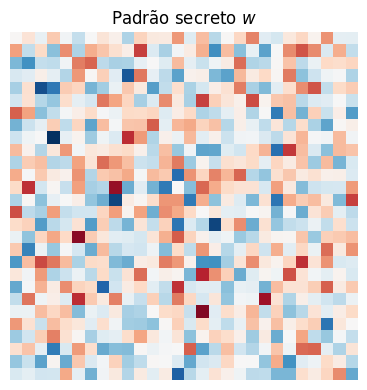

In [17]:
EPSILON        = 0.10
WM_FRACTION_SS = 0.20

# Gerado com OWNER_SEED (isolado do RNG global)
_owner_gen = torch.Generator().manual_seed(OWNER_SEED)
wm_pattern = torch.randn(1, 28, 28, generator=_owner_gen)
wm_pattern = wm_pattern - wm_pattern.mean()
wm_pattern = wm_pattern / wm_pattern.abs().max()

print(f"wm_pattern — média: {wm_pattern.mean().item():.2e}  max|w|: {wm_pattern.abs().max().item():.2f}")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(wm_pattern.squeeze(), cmap="RdBu", vmin=-1, vmax=1)
ax.set_title("Padrão secreto $w$"); ax.axis("off")
plt.tight_layout(); plt.savefig(output_dir / "ss_pattern.png", dpi=120); plt.show()

### 3.2 Dataset com marca aditiva

**Tarefa 3.2.** Implemente `SpreadSpectrumMNIST` no mesmo padrão de `VisibleWatermarkedMNIST`, mas aplicando `x' = clamp(x + EPSILON * wm_pattern, 0, 1)`. Visualize um exemplo: original, marcado, e a diferença (amplificada para ser visível).

Marcadas: 12,000 / 60,000


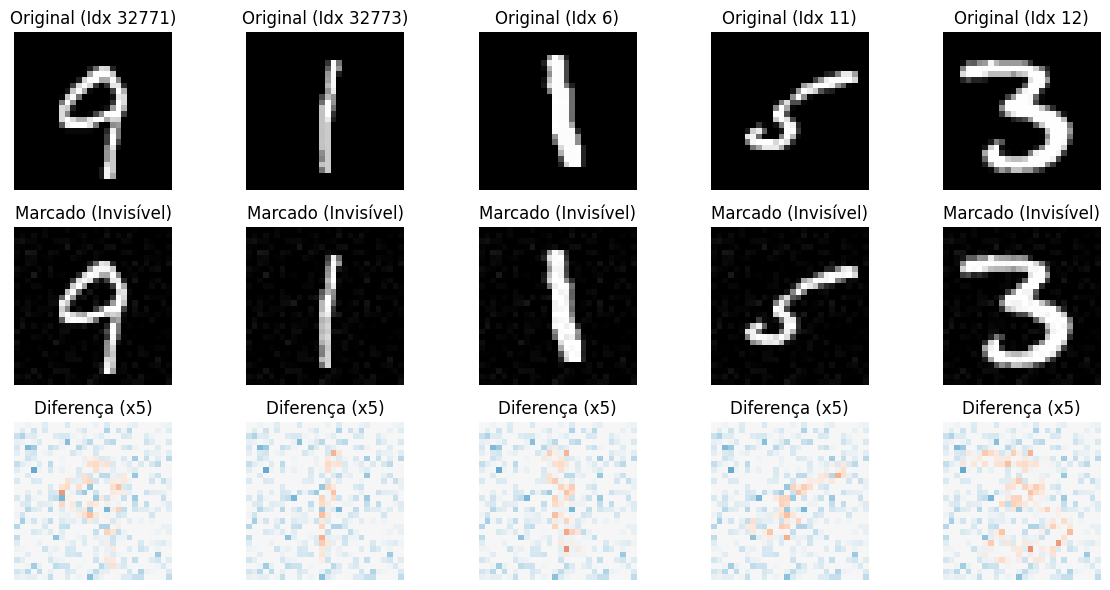

In [18]:
# 1. Função de marca d'água (Garante receber e retornar tensores PyTorch)
def apply_ss_watermark(img):
    # img e wm_pattern devem ser tensores PyTorch de formato (1, 28, 28)
    img_wm = img + EPSILON * wm_pattern
    return torch.clamp(img_wm, 0.0, 1.0)


# 2. Dataset Customizado Corrigido (com __len__ e __getitem__)
class SpreadSpectrumMNIST(Dataset):
    def __init__(self, dataset, fraction):
        self.dataset = dataset
        self.fraction = fraction
        # Usamos set() para buscas extremamente rápidas O(1) no __getitem__
        self.wm_indices = set(self._generate_watermarked_indices())

    def _generate_watermarked_indices(self):
        num_images = len(self.dataset)
        num_wm_images = int(num_images * self.fraction)
        return random.sample(range(num_images), num_wm_images)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        # Se o índice atual foi o escolhido para ser envenenado, aplica a marca
        if idx in self.wm_indices:
            img = apply_ss_watermark(img)
        return img, label


# Instanciando o dataset
ss_ds = SpreadSpectrumMNIST(train_ds, fraction=WM_FRACTION_SS)
print(f"Marcadas: {len(ss_ds.wm_indices):,} / {len(ss_ds):,}")

# 3. Função de Visualização Corrigida (com limite de amostras e tipos certos)
def visualize_watermarking(dataset_original, wm_indices, num_samples=5):
    # Pegamos apenas as primeiras 'num_samples' para não travar o Matplotlib
    sample_indices = list(wm_indices)[:num_samples]
    
    fig, axes = plt.subplots(nrows=3, ncols=len(sample_indices), figsize=(12, 6))
    
    for i, idx in enumerate(sample_indices):
        # Pegamos a imagem pura (Tensor) direto do dataset original limpo
        img_tensor, _ = dataset_original[idx]
        
        # Aplicamos a marca d'água no Tensor
        wm_tensor = apply_ss_watermark(img_tensor)
        
        # Calculamos a diferença (multiplicada por 5 para dar destaque visual)
        diff_tensor = (wm_tensor - img_tensor) * 5

        # Convertemos para NumPy APENAS na hora de plotar no matplotlib
        axes[0, i].imshow(img_tensor.squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[0, i].set_title(f"Original (Idx {idx})")
        axes[0, i].axis('off')

        axes[1, i].imshow(wm_tensor.squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[1, i].set_title("Marcado (Invisível)")
        axes[1, i].axis('off')

        # Usamos o mapa de cor RdBu para destacar o ruído adicionado
        axes[2, i].imshow(diff_tensor.squeeze().cpu().numpy(), cmap='RdBu', vmin=-1, vmax=1)
        axes[2, i].set_title("Diferença (x5)")
        axes[2, i].axis('off')

    plt.tight_layout()
    plt.show()

# Chamamos passando o dataset original LIMPO para podermos comparar a transformação
visualize_watermarking(train_ds, ss_ds.wm_indices, num_samples=5)

### 3.3 Treinar VAE com a marca imperceptível

Use `train_vae` (definida na Parte 2) para treinar `vae_ss` em `ss_ds`. Mesma arquitetura, 30 épocas.

In [21]:
ss_loader = DataLoader(ss_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

# 1. Instanciar um NOVO VAE para o experimento Spread-Spectrum
# Certifique-se de usar as variáveis globais do seu notebook (ex: LATENT_DIM e device)
vae_ss = VAE(latent_dim=LATENT_DIM).to(device)

# 2. Configurar o otimizador para este novo modelo
optimizer_ss = torch.optim.Adam(vae_ss.parameters(), lr=1e-3)

print(f"Iniciando o treinamento do VAE Spread-Spectrum ({EPOCHS} épocas)...")

# 3. Loop de Treinamento
for epoch in range(1, EPOCHS + 1):
    vae_ss.train()
    train_loss = 0
    
    for batch_idx, (data, _) in enumerate(ss_loader):
        # Mover os dados para a GPU/CPU correta
        data = data.to(device)
        
        # Zerar os gradientes do otimizador
        optimizer_ss.zero_grad()
        
        # Passada para frente (Forward pass)
        recon_batch, mu, logvar = vae_ss(data)
        
        # Calcular a função de perda do VAE (Reconstrução + KLD)
        # Nota: Ajuste o nome da função de perda caso no seu notebook ela se chame de outra forma (ex: vae_loss)
        loss = vae_loss(recon_batch, data, mu, logvar)

        # Passada para trás (Backward pass) e atualização dos pesos
        loss.backward()
        train_loss += loss.item()
        optimizer_ss.step()
    
    # Exibir o progresso do treinamento a cada poucas épocas
    if epoch % 5 == 0 or epoch == 1:
        loss_media = train_loss / len(ss_loader.dataset)
        print(f"Época {epoch:02d}/{EPOCHS} | Perda Média: {loss_media:.4f}")

# 4. Salvar os pesos do modelo treinado
# O 'output_dir' é a pasta padrão que o seu notebook está usando para salvar os arquivos (.pth e .png)
torch.save(vae_ss.state_dict(), output_dir / "vae_ss.pth")
print("\nTreinamento concluído com sucesso! Modelo salvo em 'vae_ss.pth'.")

Iniciando o treinamento do VAE Spread-Spectrum (30 épocas)...


AttributeError: 'tuple' object has no attribute 'backward'

### 3.4 Detector ingênuo de correlação (e por que ele tem um problema)

O detector natural é a **correlação** entre uma imagem gerada e o padrão secreto:

$$\text{score}(x) = \langle x,\, w \rangle = \sum_{i,j} x_{ij} \, w_{ij}$$

**Tarefa 3.4a.** Implemente `corr_score(imgs, pattern)` e calcule os scores para 2000 amostras do `model` (limpo) e 2000 do `vae_ss` (marcado). Plote ambos como histogramas sobrepostos.

In [ ]:
def corr_score(imgs, pattern):
    # TODO: produto interno por imagem
    raise NotImplementedError


N_AUDIT = 2000
model.eval(); vae_ss.eval()
# TODO: gerar amostras com o mesmo z, computar scores, plotar histogramas
raise NotImplementedError

### 3.5 Diagnóstico: por que o VAE limpo não está centrado em zero?

Você provavelmente observou que o histograma do **VAE limpo** não está centrado em $0$. Isso parece contraditório: o modelo nunca viu $w$, então a correlação não deveria ser ruído puro?

**Tarefa 3.5.** Explique matematicamente por que $\mathbb{E}[\langle x_{\text{clean}}, w \rangle] \ne 0$ em geral. Calcule numericamente o valor que causa esse desvio e mostre que ele coincide com a média empírica do histograma.

In [ ]:
# TODO: compute a imagem média do MNIST limpo (mu_mnist) e seu produto interno com wm_pattern
# Compare com a média do histograma do VAE limpo da seção anterior — devem ser parecidos.
raise NotImplementedError

### 3.6 Detector centralizado

Para o detector ser interpretável (histograma centrado em zero sob $H_0$), subtraia o offset $\langle \mu_{\text{MNIST}}, w \rangle$ centralizando as imagens antes de calcular a correlação:

$$\text{corr\_centered}(x) = \langle x - \mu_{\text{MNIST}},\, w \rangle$$

**Tarefa 3.6.** Implemente `corr_score_centered(imgs, pattern, mean_img)` e refaça o histograma. O histograma do VAE limpo deve agora aparecer próximo de zero.

In [ ]:
def corr_score_centered(imgs, pattern, mean_img):
    # TODO: <x - mean_img, pattern>
    raise NotImplementedError


# TODO: recomputar os scores e replotar o histograma centrado
raise NotImplementedError

### 3.7 Teste de hipótese

Com os scores centralizados, formalizamos a auditoria como um **teste de duas amostras**. O auditor gera $N$ amostras independentes do modelo suspeito e $N$ amostras independentes de um modelo de referência limpo, e testa se as médias diferem:

$$t = \frac{\bar{s}_{\text{ss}} - \bar{s}_{\text{clean}}}{\sqrt{(\hat{\sigma}_{\text{ss}}^2 + \hat{\sigma}_{\text{clean}}^2)/N}}$$

**Tarefa 3.7.** Gere 2000 amostras independentes de cada modelo (use `torch.randn` separado para cada). Compute `sc_clean`, `sc_ss` e o t-estatístico acima. Plote os histogramas e imprima o t-estatístico.

In [ ]:
N_AUDIT = 2000

# TODO: gerar N_AUDIT amostras INDEPENDENTES de cada modelo
# (dois torch.randn separados — não compartilhe z entre os modelos)
# Compute sc_clean e sc_ss usando corr_score_centered
# Compute o t-estatístico de duas amostras
raise NotImplementedError

### Questão 3 — Análise do detector spread-spectrum

**a)** Descreva o histograma ingênuo (Tarefa 3.4): os dois grupos estão centrados onde você esperaria? Você conseguiria detectar a marca sem ajustes?

**b)** Explique matematicamente por que o VAE limpo não está centrado em zero. Reporte o valor de $\langle \mu_\text{MNIST}, w \rangle$ que você calculou e compare com a média observada no histograma.

**c)** Após os fixes (Tarefa 3.6), os histogramas estão centrados e separados? Reporte o t-estatístico e interprete: a marca é detectável com N=2000?

*Escreva suas respostas aqui (a, b, c).*

## Parte 4 — Estudo controlado: quanto sinal e quantos dados?

A Parte 3 usou uma única configuração ($\varepsilon = 0.10$, fração $= 0.20$). Aqui mapeamos sistematicamente como a detectabilidade depende dessas escolhas.

> *Dica: você pode usar menos épocas por VAE na varredura para reduzir o tempo de execução. Se fizer isso, retreine o VAE limpo com o mesmo número de épocas antes da varredura — a comparação só é justa quando todos os modelos treinam sob as mesmas condições.*

### 4.1 Fábrica de datasets

**Tarefa 4.1.** Implemente `make_ss_dataset(eps, fraction)` que cria um dataset com `fraction` das imagens marcadas com amplitude `eps`.

In [ ]:
# TODO: escolha pelo menos 2 valores para cada parâmetro
EPSILON_VALUES  = [...]   # ex: [0.05, 0.10]
FRACTION_VALUES = [...]   # ex: [0.10, 0.20]
N_AUDIT         = 2000    # fixo
EPOCHS_ABLATION = ...     # pode ser menor que EPOCHS — veja a dica acima

def make_ss_dataset(eps, fraction, seed=SEED):
    # TODO: retornar um Dataset que aplica a marca em `fraction` das imagens de treino
    # com amplitude `eps`
    raise NotImplementedError

# Retreina o VAE limpo com EPOCHS_ABLATION para comparação justa
# TODO: chamar train_vae com train_loader, LATENT_DIM, EPOCHS_ABLATION
model_ab = ...
raise NotImplementedError

### 4.2 Varredura

**Tarefa 4.2.** Execute a varredura sobre a grade `EPSILON_VALUES × FRACTION_VALUES` (o `model_ab` já foi retreinado na 4.1 acima):
1. Para cada (ε, fração), treine um VAE marcado com `EPOCHS_ABLATION` épocas.
2. Para cada par, gere `N_AUDIT` amostras **independentes** de `model_ab` e do VAE marcado.
3. Compute o t-estatístico de duas amostras (mesma fórmula da Parte 3.7) e registre o sinal médio.

Guarde os resultados numa lista de dicts com chaves `eps`, `frac`, `signal`, `t`.

In [ ]:
# TODO: implementar a varredura
# Para cada (eps, frac) em EPSILON_VALUES × FRACTION_VALUES:
#   1. Crie o dataset com make_ss_dataset(eps, frac)
#   2. Treine um VAE com EPOCHS_ABLATION épocas
#   3. Gere N_AUDIT amostras INDEPENDENTES de model_ab e do VAE marcado
#   4. Compute o t-estatístico de duas amostras e o sinal médio
#   5. Guarde em results como dict {"eps": ..., "frac": ..., "signal": ..., "t": ...}
results = []
raise NotImplementedError

### 4.3 Visualização dos resultados

**Tarefa 4.3.** Plote dois heatmaps com eixos $(\varepsilon, \text{fração})$:
1. Sinal médio $\bar{d} = \bar{s}_{\text{wm}} - \bar{s}_{\text{clean}}$.
2. T-estatístico (duas amostras independentes).

Anote o valor em cada célula do heatmap.

In [ ]:
# TODO: heatmap signal_grid, heatmap t_grid
raise NotImplementedError

### Questão 4 — Análise dos resultados da ablação

**a)** Olhando o heatmap de sinal médio, como $\bar{d}$ cresce com $\varepsilon$ e com a fração? O crescimento é aproximadamente linear em cada eixo? Use 2–3 pares de células para justificar com números.

**b)** No heatmap de t-estatístico, qual é a menor combinação $(\varepsilon, \text{fração})$ que atinge $|t| > 3$? Existem células onde a marca não foi detectável mesmo com N=2000?

**c)** Com base nos seus resultados, qual é o par $(\varepsilon, \text{fração})$ mínimo que você recomendaria para um cenário de auditoria real? Justifique considerando tanto a detectabilidade quanto o custo de marcar os dados.

*Escreva suas respostas aqui (a, b, c).*

## Parte 5 — Extensões (Bônus)

Esta parte é **opcional**. **Escolha *uma* das duas questões abaixo** e implemente-a. Isso rende +10% na nota final.

### 5.1 — Robustez da marca a um ataque defensivo

Suponha que o dono do modelo gerador, sabendo que pode existir uma marca spread-spectrum, aplica um filtro às amostras antes de liberá-las. Implemente o ataque mais simples possível: **blur Gaussiano** nas amostras do `vae_ss` antes de calcular o score.

Rode o detector centralizado da Parte 3 em três condições: (i) sem ataque, (ii) blur com $\sigma=0.5$, (iii) blur com $\sigma=1.0$. Use $\varepsilon=0.10$, frac $=0.20$, $N=2000$.

Reporte os três valores de $t$ numa tabela e responda: o sinal sobrevive? A partir de que $\sigma$ a marca se torna indetectável ($|t| < 3$)?

*Escreva sua resposta aqui (tabela + análise).*

### 5.2 — Efeito da capacidade do canal latente

Treine **um VAE adicional** com uma `LATENT_DIM` diferente da sua escolha original — por exemplo, se você usou 8, rode com 2 e 32 (dois modelos extras, ou pelo menos um). Mantenha o restante do pipeline igual.

Refaça a auditoria da Parte 3 ($t$ em $\varepsilon=0.10$, frac $=0.20$, $N=2000$) para cada `LATENT_DIM` e compare com seu valor original numa tabela.

Em qual direção o $t$ se move quando o latente cresce? Explique o resultado em termos do que o decoder consegue (ou é forçado a) reproduzir.

*Escreva sua resposta aqui (tabela + análise).*

---

## Critérios de avaliação

| Parte | Peso | Critério |
|-------|------|----------|
| 0–1   | 20%  | VAE correto e visualizações. Q1. |
| 2     | 20%  | Marca visível e auditoria. Q2. |
| 3     | 30%  | Spread-spectrum, diagnóstico do offset, detector centralizado, teste. Q3. |
| 4     | 30%  | Ablação completa e heatmaps. Q4 com análise quantitativa. |
| 5 (bônus) | +10% | Uma das duas extensões opcionais (5.1 ou 5.2). |